# Descrevendo o movimento de um pião

* PET - Física UFRN
* Petiano: José Emanuel Vasconcelos Oliveira
* Data: 17/04/2026

$\quad$ Neste `Notebook`, vamos estudar o movimento de um dos brinquedos mais populares: o pião. Nos debruçaremos sobre o formalismo da dinâmica de corpos rígidos da mecânica analítica para entender como funciona o movimento do pião após ser lançado. Iremos modelar seu movimento, investigando como ele se mantém estável por tanto tempo. Aqui, entretanto, não iremos investir no árduo trabalho de explorar os efeitos da resistência do ar (e portanto a queda) no pião. Para soluções numéricas, usaremos rotinas consolidadas de solução de equações diferenciais para maior estabilidade. O `Notebook` seguirá a seguinte estrutura:

1. *Introdução*
2. *Solução numérica*
3. *Simulação computacional*
4. *Conclusão*

## Pré-requisitos

$\quad$ Para este `Notebook`, o leitor não deve se preocupar com bibliotecas, visto que usaremos as padrões do python. Entretanto, é aconselhável que o leitor possua um conhecimento prévio em Mecânica Lagrangiana, cálculo vetorial e diferencial.

### Importando bibliotecas

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from scipy.integrate import solve_ivp
from IPython.display import HTML, display, Math, Image

### Detalhes das bibliotecas

In [2]:
%load_ext version_information
%version_information matplotlib, numpy

Software versions
Python 3.11.15 64bit [MSC v.1942 64 bit (AMD64)]
IPython 9.10.0
OS Windows 10 10.0.26200 SP0
matplotlib 3.10.8
numpy 2.4.4
Fri Apr 17 11:57:33 2026 Hora Padrão de Buenos Aires

$\quad$ Para adicionar beleza aos gráficos, modificamos as fontes rapidamente.

In [3]:
plt.rcParams.update({
    "text.usetex": False, # Use True apenas se tiver uma distribuição LaTeX instalada no PC
    "font.family": "serif",
    "mathtext.fontset": "cm", # Usa a fonte Computer Modern (padrão do LaTeX)
    "axes.labelsize": 12
})

## 1. Introdução

$\quad$ A maior beleza da física é conseguir explicar com precisão a realidade em que vivemos. Entretanto, o uso dessa ferramenta é muitas vezes colocada simplesmente no âmbito acadêmico. As vezes, essa ciência se torna abstrata e longe demais do nosso cotidiano. Porém, não se deve enganar que ela não possa nos ajudar a entender como funciona até as coisas mais inesperadas, como as brincadeiras de criança. O pião, que fez parte da infância de muitos brasileiros, se trata de um objeto de madeira com uma ponta fina metálica. Tradicionalmente, um barbante é enrolado no corpo do objeto, sendo o intermédio para transformar a força do braço de quem arremessa em um torque que faz o brinquedo girar em torno de seu próprio eixo, quando em contato com o solo. Na brincadeira, ganha quem conseguir deixar o pião rodando por mais tempo. E isso é pura física! 

$\quad$ Antes de iniciarmos nossa descrição detalhada sobre o formalismo para entender o movimento de um pião, vamos pontuar rapidamente um tópico necessário para a construção do conhecimento necessário. O movimento de um pião pode ser estudado em dois referenciais: um em repouso, inercial, como a criança observando calmamente enquanto seu brinquedo gira; e o referencial do próprio, em rotação, não inercial. Para uma discussão mais aprofundada sobre referenciais não inerciais, sugerimos a consulta da referência [1].

$\quad$ Quando estamos lidando com esses diferentes referenciais, devemos ter muito cuidado como interpretamos as grandezas em cada um e como estas se relacionam. É possível demonstrar, por exemplo, que a velocidade medida por um referencial inercial (dito fixo) escrita a partir de informações do referencial em movimento (dito em rotação), é dada por:

$$ 
\vec{v} = \vec{V} + \vec{v}_r + \vec{\omega} \times \vec{r},
\tag{1}
$$

onde $\vec{V}$ representa a velocidade entre as origens dos sistemas de coordenadas, $\vec{v}_r$ a velocidade do corpo medida no referencial em rotação, $\vec{\omega}$ é a velocidade angular de rotação do referencial não inercial e $\vec{r}$ é a posição da particula medida no referencial girante.

$\quad$ É notório observar que o estudo em referenciais não inerciais é muito mais complicado. Entretanto, esse é um resultado introdutório e muito importante para a compreensão dos corpos rígidos. Mas afinal, o que é isso? Bom, um corpo rígido é uma idealização física e se refere a um corpo sólido cujo cada uma de suas partes estão rigidamente presos à uma única posição, quando medida da origem do seu sistema de coordenadas. O pião é uma ótima aproximação: um corpo sólido que cada parte está "presa" em si mesmo, de forma que quando medimos a posição de cada pedacinho dele em relação à sua ponta metálica, por exemplo, essa posição não varia. Nos termos da equação (1), um corpo rígido é aquele que todas as suas partículas terão $\vec{v}_r = 0$, ou seja, sem movimento relativo ao sistema girante.

$\quad$ Com a base montada, podemos adentrar de vez no formalismo adequado. Aqui não iremos desenvolver todas as contas  e particularidades desse tópico tão bonito e elegante da mecânica clássica. Para uma leitura mais aprofundada, recomendamos as referências [1,2].

### 1.1 Formalismo da dinâmica de corpos rígidos

#### 1.1.1 Tensor de inercia

$\quad$ Um dos principais resultados da mecânica consiste na equação de movimento, dada pela segunda Lei de Newton, na forma translacional e rotacional:

$$
\vec{F} = \frac{d \vec{P}}{dt} \quad ; \quad \vec{N} = \frac{d \vec{L}}{dt},
$$

onde $\vec{F}$ é a força resultante sobre o sistema, $\vec{P}$ o momento linear total, $\vec{N}$ o torque resultante e $\vec{L}$ o momento angular total. Assim como as demais leis de Newton, estas só funcionam para um referencial inercial. Para um corpo rígido em rotação, portanto, essas equações não possuem validade. Entretanto, a análise pode ser feita tomando como referência um ponto específico desse corpo, desde que esta esteja em repouso com relação a um referencial inercial, ou então o seu centro de massa. Assim, em nosso estudo, limitamos que o nosso pião (a que iremos retratar como corpo rígido) pode apenas rotacionar e, no máximo, transladar com velocidade constante. 

$\quad$ Assim, seja $O$ um ponto fixo do corpo rígido (como a ponta metálica do pião), ou seu centro de massa, calculemos seu momento angular total. Sabemos que este pode ser escrito por: 

$$
\vec{L} = \sum_{k=1}^N \vec{r}_k \times \vec{p}_k = \sum_{k=1}^N m_k \ \vec{r}_k \times \vec{v}_k, 
$$

onde $N$ é o número total de partículas constituintes do corpo e o índice $k$ refere-se às grandezas da $k$-ésima partícula. É importante notar que a velocidade $\vec{v}_k$ refere-se àquela calculada no referencial fixo. Usando a equação (1), fazemos a substituição de forma que obtemos:

$$
\vec{L} = \sum_{k=1}^N m_k \ \vec{r}_k \times (\vec{\omega} \times \vec{r}_k),
$$

onde a velocidade entre referenciais foi emitida naturalmente pois sempre é possível escolher um referencial inercial em que o ponto $O$ esteja em repouso, visto que este só translada com velocidade constante, conforme estabelecido. É de se ficar claro que o vetor $\vec{r}_k$ é medido sempre a partir do ponto $O$. Agora, usamos a identidade vetorial:

$$
\vec{a} \times \left(\vec{b} \times \vec{c}\right) = \left(\vec{a} \cdot \vec{c}\right) \ \vec{b} - \left(\vec{a} \cdot \vec{b}\right) \ \vec{c},
$$

transformando a expressão anterior em:

$$
\vec{L} = \sum_{k=1}^N m_k \left[r_k^2 \ \vec{\omega} - \left(\vec{r}_k \cdot \vec{\omega}\right) \ \vec{r}_k\right]. 
\tag{2}
$$

$\quad$ Para facilitar o entendimento, convém utilizar uma notação indicial. Assim, escrevemos as coordenadas a partir da seguinte relação: $x_1 = x; \  x_2 = y;\  x_3 = z$. Dessa forma, tomando a $i$-ésima componente da equação (2), teremos:

$$
L_i = \sum_{k=1}^N m_k \ r_k^2 \ \omega_i - \sum_{k=1}^N \sum_{j=1}^3 m_k\ x_j \ x_i \ \omega_j.
$$

É válido notar que cada coordenada é calculada separadamente para cada partícula. O índice $k$ que faz tal referência foi omitido por obviedade e por enxugar a notação. Como forma de fazer as duas parcelas percorrerem os mesmos somatórios, podemos usar uma propriedade extremamente conhecido em tratamentos vetoriais:

$$
\omega_i = \sum_j \omega_j \delta_{ij},
$$

onde $\delta_{ij}$ é a função delta de Kronecker. Ela é nula para qualquer combinação dos índices $i$ e $j$, exceto para quando $i=j$, na qual ela assume valor 1. Fazendo uso dessa função, escrevemos então:

$$
L_i = \sum_{k=1}^N \sum_{j=1}^3 m_k \left(r_k^2 \ \delta_{ij} - x_j \ x_i \right) \omega_j = \sum_{j=1}^3 \left[\sum_{k=1}^N m_k \left(r_k^2 \ \delta_{ij} - x_j \ x_i \right)\right] \omega_j.
\tag{3}
$$

Dizemos que o termo entre colchetes da equação (3) são as componentes $I_{ij}$ do tensor de inércia. Caso não tenha ficado claro até então, $r_k^2 = x_1^2 + x_2^2+x_3^2$. Assim, a $i$-ésima componente do momento angular é calculada por:

$$ L_i = \sum_{j=1}^3 I_{ij} \omega_j \implies \vec{L} =\mathbf{I} \cdot \vec{\omega}. \tag{4} $$

É necessário dizer que o produto com o tensor de inércia deve ser feito conforme o produto matricial, onde os vetores são retratados como matrizes coluna.

$\quad$ Entretanto, para muitos problemas de corpos rígidos (como é o caso do nosso pião), mudamos a visão sobre o corpo. Deixamos de tratá-lo como um conjunto de partículas discretas e assumimos que se trata, na verdade, de um contínuo de massa. Assim, no cálculo das componentes do tensor de inércia, o somatório dá lugar para uma integral:

$$
I_{ij} = \int \rho \left(r^2 \ \delta_{ij} - x_j \ x_i \right) dV, 
$$

onde $\rho$ é a densidade de massa em cada ponto e a integração é feita sobre todo o volume do corpo. O tensor de inércia pode ser representado por uma matriz, na forma:

$$
\mathbf{I} = 
\begin{bmatrix}
    I_{xx} & I_{xy} & I_{xz} \\
    I_{yx} & I_{yy} & I_{yz} \\
    I_{zx} & I_{zy} & I_{zz}
\end{bmatrix}
=
\begin{bmatrix}
    \int (y^2 + z^2) \rho \, dV & -\int xy \rho \, dV & -\int xz \rho \, dV \\
    -\int yx \rho \, dV & \int (x^2 + z^2) \rho \, dV & -\int yz \rho \, dV \\
    -\int zx \rho \, dV & -\int zy \rho \, dV & \int (x^2 + y^2) \rho \, dV
\end{bmatrix}
.
\tag{5}
$$

$\quad$ Para uma rápida análise, vamos entender como pode ser expressa a energia cinética. Novamente, consideramos um referencial inercial de tal forma que o ponto $O$ do corpo rígido esteja em repouso. Isso significa que tal energia cinética será dada exclusivamente pelo processo rotacional. Teremos que:

$$
T = \frac{1}{2} \sum_{k=1}^N m_k \ (\vec{v}_k \cdot \vec{v}_k).
$$

Novamente, usamos a expressão (1) para, convenientemente, expresar apenas um dos vetores velocidades. Escrevemos então:

$$
T = \frac{1}{2}\sum_{k=1}^N m_k \ \vec{v}_k \cdot(\vec{\omega} \times \vec{r}_k). 
$$

Utilizando a regra cíclica: $\vec{a} \cdot (\vec{b} \times \vec{c}) = \vec{c} \cdot (\vec{a} \times \vec{b}) = \vec{b} \cdot (\vec{c} \times \vec{a})$, rearranjamos:

$$
T = \frac{1}{2} \vec{\omega} \cdot \sum_{k=1}^N (\vec{r}_k \times m_k \vec{v}_k) = \frac{1}{2} \vec{\omega} \cdot \vec{L}.
\tag{6}
$$

#### 1.1.2 Momentos principais de inercia

$\quad$ Agora que conhecemos os termos introdutórios e principais, vamos mais afundo no estudo dos corpos rídigos. Como vimos, as expressões para o momento angular e para a energia cinética são extremamente trabalhosas de serem calculadas. O trabalho é muito simplificado se o o tensor for diagonalizado, de forma que as expressões se tornam:

$$
T  = \frac{1}{2}\sum_{i=1}^3 I_i \omega_i^2.
$$

$$
L_i = I_i \omega_i \implies \vec{L} = \sum_{i=1}^3 I_i \omega_i \hat{e}_i \ .
$$

$\quad$ Isso significa que, para um tensor de inércia diagonal, se o corpo gira sobre um eixo principal de inércia (eixos do corpo em que os produtos de inércia, ou seja, os elementos situados fora da diagonal principal do tensor, se anulam), o momento angular e a velocidade angular apontam na mesma direção. Como o tensor muda a depender do sistema de coordenadas, uma mudança de base para o sistema que diagonalize o tensor é extremamente conveniente. Mas, como fazer essa mudança de base? Bom, independente do sistema de coordenadas, a física não pode mudar. Então, se existe algum eixo pelo qual um corpo rígido possa girar de forma que seu momento angular aponte na mesma direção da velocidade angular, pouco importa em qual sistema de coordenadas escreveremos esse eixo. Isso significa que no sistema em que o tensor de inércia foi calculado, deve existir algum vetor de velocidade angular que gere um momento angular proporcional a ele. Assim, se rotacionarmos os eixos de forma a coincidir com o vetor da velocidade angular, então aí o tensor se torna diagonal. Em termos matemáticos, isso significa que devemos procurar:

$$
\mathbf{I} \cdot \vec{\omega} = I \  \vec{\omega}.
$$

Fazendo o bom uso da manipulação matricial, podemos escrever:

$$
(\mathbf{I} - I \mathbb{1}) \cdot \vec{\omega} = 0.
$$

Para não haver confusão, devemos esclarecer a notação utilizada: $\mathbf{I}$ representa o tensor de inércia no sistema de coordenadas inicial, $I$ representa o momento de inércia e é um escalar e $\mathbb{1}$ é a matriz identidade $3 \times 3$. A equação anterior só apresenta soluções não triviais, ou seja, soluções na qual $\vec{\omega} \neq 0$, se o termo entre parênteses, que é uma matriz, não admitir inversa. Da álgebra linear, sabemos que uma matriz não admite inversa se o seu determinante for nulo. Portanto, devemos resolver:

$$
\det(\mathbf{I} - I\mathbb{1}) = 0 \implies \begin{vmatrix}
    I_{11} - I & I_{12} & I_{13} \\
    I_{21} & I_{22} - I & I_{23} \\
    I_{31} & I_{32} & I_{33} - I
\end{vmatrix} = 0.
\tag{7}
$$

$\quad$ O desenvolvimento da equação (7) leva à equação secular para $\mathbf{I}$, que é cúbica. Em outra linguagem, o problema de diagonalizar um vetor nada mais é que o clássico problema de autovalores e autovetores. Os momentos de inércia $I$ são os autovalores, enquanto que as direções de rotação que satisfazem a equação (os autovetores) definem os eixos principais de inércia. Por fim, a solução desse problema indica que, um sistema de coordenadas orientado na base ortonormal dos autovetores, gera um tensor de inércia diagonal, onde cada elemento corresponde a um dos autovalores, denominados $I_1, I_2$ e $I_3$.

#### 1.1.3 Ângulos de Euler

$\quad$ Sabemos que a transformação de coordenadas entre o referencial inercial e o referencial no corpo se torna corriqueiro. Assim, para a formulação Lagrangeana da dinâmica do corpo rídigo, convém adotar uma maneira de levar coordenadas nos eixos inerciais para coordenadas em eixos fixos ao corpo. A utilização dos cossenos diretores não é adequada, por não serem totalmente independentes entre si. Uma escolha particular para uma matriz de rotação e que têm grande valor prático é aquela escrita em termos de três ângulos independentes: os ângulos de Euler.

$\quad$ Afinal, o que buscamos é levar a partir de rotações, um sistema de coordenadas até outro. Para isso, consideramos que ambas origens estão localizadas no ponto $O$ definido anteriormente. Assim, nosso objetivo é escrever as coordenadas $\vec{r}$ do corpo em termos das coordenadas $\vec{r}'$ do referencial fixo na forma: 

$$
\vec{r} = \mathbf{\Gamma} \vec{r}',
$$

onde $\mathbf{\Gamma}$ representa uma matriz de rotação em termos dos ângulos de Euler que iremos determinar.

$\quad$ Ao utilizar ângulos de Euler para determinar rotações, dividimos o processo em 3. Primeiro, uma rotação no sentido anti-horário em torno do eixo $z$ por um ângulo $\phi$. Este é o chamado ângulo de precessão, que retrata as rotações do corpo em torno do eixo $z$ fixo. A matriz de rotação para esse primeiro ângulo é dada por:

$$
\mathbf{\Phi} = 
\begin{bmatrix}
    \cos\phi & \sin\phi & 0 \\
    -\sin\phi & \cos\phi & 0 \\
    0 & 0 & 1
\end{bmatrix}
.
$$

Como as sucessivas rotações dependem da configuração anterior, vamos adotar sistemas de coordenadas intermediários. Por exemplo, a primeira rotação gera novos eixos coordenados, relacionados com o original na forma:

$$
\vec{r}_1 = \mathbf{\Phi}\vec{r}'.
$$

A segunda rotação é feita por um ângulo $\theta$ no sentido anti-horário em torno do eixo $x_1$, ou seja, da componente $x$ do sistema após sofrer a rotação determinada pelo ângulo $\phi$. $\theta$ também é chamado de ângulo de nutação e descreve os movimentos de "queda" e "subida" do corpo rígido. Sua matriz de rotação é dada por:

$$
\mathbf{\Theta} = 
\begin{bmatrix}
    1 & 0 & 0 \\
    0 & \cos\theta & \sin\theta \\
    0 & -\sin\theta & \cos\theta
\end{bmatrix}.
$$

Dessa forma, definimos outro sistema de coordenadas, dado pela sucessiva rotação do sistema, de forma:

$$
\vec{r}_2 = \mathbf{\Theta}\vec{r}_1.
$$

Vale destacar que o eixo $x_1 = x_2$ é chamado de linha nodal e descreve a interseção  entre os planos $x-y$ original e após a segunda rotação.  

$\quad$ Por fim, a última rotação é dada em torno do eixo $z_2$. Essa é feita no sentido anti-horário por um ângulo $\psi$. Esse ângulo descreve a rotação do corpo em torno de seu próprio eixo $z$. Analogamente, a matriz de rotação é dada por:

$$
\mathbf{\Psi} = 
\begin{bmatrix}
    \cos\psi & \sin\psi & 0 \\
    -\sin\psi & \cos\psi & 0 \\
    0 & 0 & 1
\end{bmatrix}.
$$

Finalmente, após essas rotações, chegamos no sistema de coordenadas do corpo. Basicamente, fizemos o seguinte algoritmo: Identificamos em que lugar o corpo se encontra no plano $x-y$, depois adaptamos o sistema para quanto o corpo "caiu" e, por fim, quanto ele girou em torno de si mesmo. É de se ficar claro portanto que a última transformação é dada por:

$$
\vec{r} = \mathbf{\Psi}\vec{r}_2.
$$

Porém, o vetor $\vec{r}_2$ é dado em termos de $\vec{r}_1$, que por sua vez é dado em termos de $\vec{r}'$. Fazendo as substituições adequadas, chegamos portanto que:

$$
\vec{r} = \mathbf{\Psi}\mathbf{\Theta}\mathbf{\Phi}\vec{r}',
$$

onde as aplicações são feitas da direita para a esquerda. Isso significa que a matriz de rotação total é dada por:

$$
\mathbf{\Gamma} = \mathbf{\Psi} \mathbf{\Theta} \mathbf{\Phi}.
$$

Substituindo as representações matriciais e realizando os produtos adequadamente, obtemos finalmente que:

$$
\mathbf{\Gamma} = 
\begin{bmatrix}
    \cos\psi\cos\phi - \cos\theta\sin\phi\sin\psi  & \cos\psi\sin\phi + \cos\theta\cos\phi\sin\psi & \sin\psi\sin\theta \\
    -\sin\psi\cos\phi - \cos\theta\sin\phi\cos\psi & -\sin\psi\sin\phi + \cos\theta\cos\phi\cos\psi & \cos\psi\sin\theta \\
    \sin\theta\sin\phi & -\sin\theta\cos\phi & \cos\theta
\end{bmatrix}.
$$

Um fato interessante sobre a matriz de rotação total, $\mathbf{\Gamma}$, é que ela é ortogonal. Isso significa que, se quisermos sair das coordenadas do corpo e irmos para as coordenadas do referencial fixo, basta tomarmos a transposta da matriz, na forma

$$
\vec{r}' = \mathbf{\Gamma}^T \vec{r}
$$

$\quad$ A seguir, mostramos uma figura retratando a rotação total em termos dos ângulos de Euler. Nessa figura, o sistema fixo está descrito em preto e com as letras maiúsculas, enquanto o sistema do corpo está em vermelho, com as letras minúsculas. É importante notar também a presença da linha nodal, destacada em verde na imagem.

<img src="../Imagens/pião/angEuler.jpg" width="30%">

Também trazemos um GIF ilustrativo que mostra a rotação de uma esfera a partir dos 3 ângulos de Euler descritos. Nele, está o algoritmo descrito. Coloca-se o corpo no referencial inercial e as rotações tentam levá-lo para sua posição original.

<img src="../Imagens/pião/Euler2.gif" width="250">

Pela forma com que são definidos, os ângulos de Euler podem assumir os seguintes valores:

$$
0 \leq \phi \leq 2 \pi \quad ; \quad 0 \leq \theta \leq \pi \quad; \quad 0 \leq \psi \leq 2 \pi.
$$

$\quad$ Agora que conseguimos encontrar a matriz geradora de rotações, convém também exprimir o vetor velocidade angular responsável pela rotação do corpo, no sistema de coordenadas do próprio corpo. Podemos associar cada rotação à um vetor de velocidade angular, e portanto, a velocidade angular total é dada simplesmente pela soma vetorial destes. Em outros termos, 3 rotações foram realizadas, uma em cada sistema de coordenadas, sendo elas $\vec{\omega}_{\phi}, \vec{\omega}_{\theta}$ e $\vec{\omega}_{\psi}$. Logicamente, a velocidade total é expressa pela soma: $\vec{\omega} = \vec{\omega}_{\phi} + \vec{\omega}_{\theta} + \vec{\omega}_{\psi}$. Nosso objetivo é, portanto, exprimir cada velocidade associada à rotação específica no sistema de coordenadas do corpo.

$\quad$ Vamos por partes. A primeira rotação é feita pelo ângulo $\phi$. Podemos dizer, sem perda de generalidade, que a velocidade angular associada possui magnitude igual à $\dot{\phi}$ e aponta no sentido positivo do eixo $z'$, visto que a rotação é feita no sentido anti-horário (lembre da regra da mão direita). Como o eixo $z'$ coincide com o eixo $z_1$, então devemos fazer a transformação:

$$
\vec{\omega}_{\phi} = \mathbf{\Psi}\mathbf{\Theta} \left(\dot{\phi} \hat{z}_1\right),
$$

onde $\hat{z}_1$ representa o versor na direção do eixo $z_1$. Novamente, lembre que os vetores sem linha e índices significam que eles estão escritos no eixo de coordenada do corpo. Aplicando adequadamente as matrizes de rotação explicadas anteriormente, obtemos rapidamente:

$$
\vec{\omega}_{\phi} = \dot{\phi} \sin{\theta} \sin{\psi}  \ \hat{x} + \dot{\phi} \sin{\theta} \cos{\psi}  \ \hat{y} + \dot{\phi} \cos{\theta} \ \hat{z} .
$$

$\quad$ A próxima rotação é feita através da linha de nós por um ângulo $\theta$ no sentido horário. Isso significa que a velocidade angular correspondente à essa rotação é dada no eixo $x_1$, que coincide com $x_2$. Analogamente, a magnitude é dada por $\dot{\theta}$. Dessa vez, o vetor não precisa sofrer a transformação completa, apenas ser ajustado na forma:

$$
\vec{\omega}_{\theta} = \mathbf{\Psi}(\dot{\theta} \hat{x}_2),
$$

visto que uma rotação já foi realizada. Fazendo a aplicação matricial, chegamos facilmente em:

$$
\vec{\omega}_{\theta} = \dot{\theta} \cos\psi \, \hat{x} - \dot{\theta} \sin\psi \, \hat{y}
$$

$\quad$ Por fim, precisamos escrever a velocidade da última rotação. Porém, esta é feita sobre um eixo já fixo no corpo. Isso significa que ela não precisa ser transformada, pois já é escrita no referencial do corpo. Isso é tão verdade pois a rotação é feita sobre o eixo $z$ no sentido anti-horário. A magnitude desta é dada por $\dot{\psi}$, de forma que temos simplesmente:

$$
\vec{\omega}_{\psi} =  \dot{\psi} \, \hat{z}.
$$

$\quad$ Agora, com as velocidades de cada rotação obtidas, somamos vetorialmente cada um dos vetores de forma a obter a velocidade angular total em termos apenas dos ângulos de Euler. Em notação indicial, teremos finalmente que:

$$
\begin{aligned}
        \omega_1 &= \dot{\phi} \sin\theta \sin\psi + \dot{\theta} \cos\psi \\
        \omega_2 &= \dot{\phi} \sin\theta \cos\psi - \dot{\theta} \sin\psi \\ 
        \omega_3 &= \dot{\phi} \cos\theta + \dot{\psi}
\end{aligned}
\tag{8}
$$

com

$$
\vec{\omega} = \omega_1 \ \hat{x} + \omega_2 \ \hat{y} + \omega_3 \ \hat{z}.
$$

A escrita da velocidade angular dessa maneira será de muita importância futuramente.

#### 1.1.4 Equações de Euler para um corpo rígido

$\quad$ Agora que aprendemos um método conveniente de transformação de coordenadas, vamos explorar esse conhecimento com outras propriedades discutidas anteriormente. Então, seja $\vec{N}$ o torque aplicado ao ponto $O$ de um corpo rígido, do ponto de vista do referencial inercial, podemos escrever:

$$
\vec{N} = \left(\frac{d\vec{L}}{dt}\right)_{Inercial}.
$$

Deixamos o subescrito para evidenciar que a variação do momento angular é medida no referencial inercial. Utilizando o formalismo de referenciais não inerciais - consulte [1] -, obtemos: 

$$
\vec{N} = \left(\frac{d\vec{L}}{dt}\right)_{Corpo} + \vec{\omega} \times \vec{L}.
$$

$\quad$ Para eixos fixos no espaço, a rotação do corpo faria com que as componentes do tensor de inércia variassem com o tempo. Entretanto, usando eixos fixos ao corpo, esse problema é superado. Além disso, é mais conveniente ainda se a transformação de coordenadas for tal que os eixos do corpo coincidam com os eixos principais de inércia. É nisso que iremos nos ater, pois é extremamente facilitador. Escrevendo a equação anterior em componentes:

$$
N_1 = \frac{dL1}{dt} + \omega_2L_3 - \omega_3L_2.
$$

Note que o subescrito foi retirado pela adoção do sistema explicado anteriormente. Além disso, lembrando que para eixos principais de inércia $L_i = I_i \omega_i$, com os momentos de inércia constantes, pois o sistema de coordenadas é preso ao corpo:

$$
N_1 = I_1 \frac{d \omega_1}{dt} + \omega_2 I_3\omega_3 - \omega_3I_2\omega_2 \implies N_1 = I_1 \dot{\omega}_1 - \omega_2\omega_3(I_2-I_3).
$$

É facil notar que a mesma estrutura para as outras coordenadas, apenas fazendo permutação nos índices. Assim, podemos generalizar essa expressão para:

$$
\begin{aligned}
    I_1 \dot{\omega}_1 - (I_2 - I_3) \omega_2 \omega_3 &= N_1 \\
    I_2 \dot{\omega}_2 - (I_3 - I_1) \omega_3 \omega_1 &= N_2 \\
    I_3 \dot{\omega}_3 - (I_1 - I_2) \omega_1 \omega_2 &= N_3
\end{aligned}
$$

Essas são as equações de Euler para um corpo rígido e descrevem o movimento do eixo de rotação instantâneo (definido pela velocidade angular) relativamente a um referencial fixo no corpo, particularmente alinhado com os eixos principais de inércia. Essas equações são extremamente facilitadas para casos onde há simetria, que será o nosso caso de interesse.

### 1.2 Pião simétrico sobre um ponto fixo

$\quad$ Com o formalismo dos corpos rígidos devidamente estabelecidos, podemos finalmente estudar nosso caso específico: um pião, cujo seu ponto de contato com o chão pode, no máximo, se movimentar com velocidade constante. Vamos modelar nosso brinquedo como um cone invertido homogêneo, de altura $h$, massa $m$ e raio maior $R$. A primeira coisa que faremos é calcular o tensor de inércia, conforme manda (5). Supomos que o cálculo é feito com o vértice do cone situado na origem do sistema cartesiano tradicional, com o eixo $z$ coincidindo com o eixo de simetria do pião (coincide com a ponta metálica). Os cálculos são elementares, mas desagradavelmente extensos. Para brevidade, não calcularemos os elementos. O tensor resultante é dado por:

$$
    \mathbf{I} = \frac{3}{20}m 
    \begin{bmatrix}
        R^2 + 4h^2 & 0 & 0 \\
        0 & R^2 + 4h^2 & 0 \\
        0 & 0 & 2R^2
    \end{bmatrix}
    .
$$

Note que o tensor de inércia já é diagonal. Isso significa que cada um dos elementos é um momento principal de inércia. Os eixos principais de inércia são os próprios eixos cartesianos. É fácil observar que $I_1 = I_2$. Essa é exatamente a característica que define um pião simétrico: 2 dos seus momentos principais de inércia são idênticos.

$\quad$ Mesmo com tal simetria, o uso exclusivo das equações de Euler não auxilia na obtenção de bons resultados. Por esse motivo, faremos uso do formalismo Lagragiano que é muito facilitador. A mecânica Lagrangiana é formulada na análise das energias de um sistema. Como o pião pode transladar apenas com velocidade linear constante, sempre é possível escolher um referencial para que essa se anule, de forma que não nos causará problemas. Assim, apenas a energia cinética rotacional e a energia potencial gravitacional entram em jogo. Supomos que o pião esteja sobre ação de um campo gravitacional uniforme, apontado na direção negativa do eixo $z'$, com módulo $g = 9,81 \ \text{m/s}^2$. Consideramos que a distância entre o ponto de apoio e o centro de massa do pião seja $l$. Um esquema retirado da referência [2] está mostrado a seguir, facilitando a visualização e entendimento do sitema.

<img src="../Imagens/pião/Piaosimetrico.png" width="30%">

$\quad$ Agora, montemos nossa Lagrangiana. Como os eixos do corpo já são eixos principais de inércia, podemos usar a forma da energia cinética mostrada na respectiva seção. Além disso, usaremos as velocidades angulares em termos dos ângulos de Euler anteriormente mostradas. A energia cinética se tornará então:

$$
T = \frac{1}{2} I_1 (\omega_1^2+\omega_2^2) + \frac{1}{2}I_3 \omega_3^2 \implies  T = \frac{1}{2} I_1 (\dot{\phi}^2 \sin^2\theta + \dot{\theta}^2) + \frac{1}{2} I_3 (\dot{\phi} \cos\theta + \dot{\psi})^2.
$$

A única energia potencial envolvida é a gravitacional, dada por:

$$
V = mgl\cos{\theta}.
$$

Como a Lagrangiana é dada por $L = T- V$, teremos portanto:

$$
L = \frac{1}{2} I_1 (\dot{\phi}^2 \sin^2\theta + \dot{\theta}^2) + \frac{1}{2} I_3 (\dot{\phi} \cos\theta + \dot{\psi})^2 - mgl\cos{\theta}.
$$

$\quad$ Note que a Lagrangiana é cíclica sobre as coordenadas $\phi$ e $\psi$. Isso significa que os momentos conjugados das respectivas coordenadas são constantes de movimentos. Como as coordenadas são ângulos, isso significa que os momentos angulares referentes à eles são constantes. Obtemos os momentos conjugados a partir de:

$$
\begin{aligned}
p_\psi = \frac{\partial L}{\partial \dot{\psi}} = I_3 (\dot{\phi} \cos\theta + \dot{\psi}) = \ &I_3 \omega_3 = \text{constante} \\
p_\phi = \frac{\partial L}{\partial \dot{\phi}} = (I_1 \sin^2\theta + I_3 \cos^2\theta) \dot{\phi} + \ &I_3 \dot{\psi} \cos\theta = \text{constante}
\end{aligned}
$$

Além disso, notamos que a Lagrangiana não depende explicitamente do tempo. Além disos, a energica cinética é função homogênea do segundo grau das velocidades. Isso, portanto, implica que a energia também é uma constante de movimento:

$$
E = \frac{1}{2} I_1 (\dot{\phi}^2 \sin^2\theta + \dot{\theta}^2) + \frac{1}{2} I_3 (\dot{\phi} \cos\theta + \dot{\psi})^2 + mgh \cos\theta = \text{constante}.
$$

Usando a relação de $p_{\psi}$, podemos obter ainda outra constante de movimento. Primeiro, escrevemos que:

$$
\frac{p_{\psi}^2}{2I_3} = \frac{I_3}{2}(\dot{\phi} \cos\theta + \dot{\psi})^2 = \text{constante}.
$$

Subtraindo esse termo na energia, obtemos a constante:

$$
E'  = \frac{1}{2} I_1 (\dot{\phi}^2 \sin^2\theta + \dot{\theta}^2) + mgh \cos\theta.
$$

Além disso, das relações dos momentos, podemos escrever:

$$
\begin{aligned}
\dot{\psi} + \dot{\phi}\cos{\theta} = \frac{p_{\psi}}{I_3}, \\ \\
\dot{\phi} = \frac{p_{\phi} - p_{\psi}\cos{\theta}}{I_1\sin^2{\theta}}.
\end{aligned}
$$

Usando a relação de $\dot{\phi}$ em $E'$, chegamos finalmente que:

$$
E' = \frac{1}{2} I_1 \dot{\theta}^2 + V_{ef}(\theta),
\tag{9}
$$

onde,

$$
V_{ef}(\theta) = \frac{(p_\phi - p_\psi \cos\theta)^2}{2 I_1 \sin^2\theta} + Mgh \cos\theta,
$$

é dito o potencial efetivo.

$\quad$ Teoricamente, a solução analítica está completamente feita. A solução para a equação (9) é dada por separação de variáveis, com resultado imediato:

$$
\sqrt{\frac{2}{I_1}}t = \int_{\theta_0}^{\theta} \frac{d\theta}{\left[E' - V_{ef}(\theta)\right]^{1/2}},
$$

de forma que $\theta_0$ representa o ângulo inicial de lançamento, ou seja, o valor de $\theta$ para $t = 0$. Com uma inversão adicional, é possível obter $\theta(t)$. Com isso, $\phi(t)$ é rapidamente determinado. Posteriormente, $\psi(t)$ é obtido pela relação descrita anteriormente. Entretanto, como o leitor deve imaginar, esse é um trabalho extremamente árduo, visto que a integral anterior não pode ser obtida em termos de funções elementares.

$\quad$ Porém, as análises físicas não estão estritamente amarradas à essa determinação, podendo ser feitas pelas análises das equações anteriores. Para detalhamento mais aprofundado, vale a consulta às referências [1,2]. Aqui, faremos apenas análises úteis e determinantes para o nosso caso.

$\quad$ Para nós, o mais importante é entender o que significa o potencial efetivo. Como será mostrado futuramente, o gráfico do potencial diverge para $\theta = 0$ e $\theta = \pi$. Entre esses valores, o gráfico assume a forma de um poço de potencial. Isso significa que, para um dado valor de $E'$, o pião está confinado a se mover entre dois ângulos $\theta_1$ e $\theta_2$, tais que $V_{ef}(\theta_1) = V_{ef}(\theta_2) = E'$.

$\quad$ Mas qual a forma desses movimentos? Bom, pela expressão que relaciona $\dot{\phi}$ com os momentos conjugados, tudo depende da razão entre os momentos. Se a razão for tal que o sinal de $\dot{\phi}$ não mude, o eixo de simetria executa o processo de nutação entre os ângulos delimitadores, se movendo monotomicamente entre eles com uma projeção em formato de ondas. Caso $\dot{\phi}$ troque de sinal durante a nutação, o eixo fará um movimento parecido com laços. Finalmente, se os valores dos momentos forem tais que:

$$
(p_{\phi} - p_{\psi} \cos \theta) \big|_{\theta = \theta_1} = 0,
$$

então:

$$
\dot{\phi} \big|_{\theta = \theta_1} = 0, \quad \dot{\theta} \big|_{\theta = \theta_1} = 0,
$$

e o movimento será do tipo cúspide.

## 2. Solução numérica

$\quad$ Como vimos anteriormente, soluções analíticas não podem ser expressas em termos de funções elementares. Assim, a resolução do problema estará totalmente ancorada em métodos computacionais. A nossa abordagem será praticamente a mesma que para a solução analítica, exceto a obtenção do ângulo $\theta$. Ao invés de obtê-lo via integração, vamos obter utilizando técnica de solução de sistemas de equações diferenciais. Para um maior aprofundamento nesse tema, sugerimos a referência [3]. Primeiro, vamos utilizar a equação de Euler-Lagrange para a variável $\theta$, a partir da Lagrangiana calculada anteriormente:

$$
\frac{d}{dt}\left(\frac{\partial L}{\partial \dot{\theta}}\right) - \frac{\partial L}{\partial \theta} = 0.
$$

Primeiro, calculamos o termo da derivada temporal:

$$
\frac{\partial L}{\partial \dot{\theta}} = I_1 \dot{\theta} \implies \frac{d}{dt}\left(\frac{\partial L}{\partial \dot{\theta}}\right) = I_1 \ddot{\theta}.
$$

Agora, a derivada em relação à coordenada, lembrando que $\omega_3 = \dot{\phi} \cos\theta + \dot{\psi}$:

$$
\begin{aligned}
\frac{\partial L}{\partial \theta} = I_1 \dot{\phi}^2 \sin\theta \cos\theta + I_3 \omega_3 \underbrace{\frac{\partial \omega_3}{\partial \theta}}_{-\dot{\phi}\sin\theta} + mgh \sin\theta, \\
\implies 
\frac{\partial L}{\partial \theta} = I_1 \dot{\phi}^2 \sin\theta \cos\theta - I_3 \omega_3 \dot{\phi} \sin\theta + mgh \sin\theta.
\end{aligned}
$$

Substituindo na equação de Euler-Lagrange e rearranjando os termos, teremos:

$$
I_1 \ddot{\theta} = I_1 \dot{\phi}^2 \sin\theta \cos\theta - I_3 \omega_3 \dot{\phi} \sin\theta + mgh \sin\theta.
$$

$\quad$ Para resolver o sistema, fazemos uso de uma variável auxiliar, de forma que:

$$
\begin{aligned}
    \frac{d\theta}{dt} &= \omega_{\theta}, \\ \\
    \frac{d \omega_{\theta}}{dt} &= \frac{1}{I_1} \left( I_1 \dot{\phi}^2 \sin\theta \cos\theta - I_3 \omega_3 \dot{\phi} \sin\theta + mgh \sin\theta \right).
\end{aligned}
$$

Com o sistema organizado dessa maneira, podemos usar métodos como a integração por Runge-Kutta. Para melhor performace, usaremos a rotina `RK45` da função *solve.ivp* da biblioteca *SciPy*. Esse método de integração é muito preciso e estável, além de muito eficiente. O desenvolvimento do algoritmo de Runge-Kutta poderia ter sido feito manualmente, porém seria muito mais ineficiente que a função otimizada utilizada. Para maior detalhamento sobre o método Runge-Kutta e sobre a rotina `RK45`, consultar as referências [3,4].

$\quad$ Com a rotina estabelecida, usamos o método de problema de valor inicial. Assumimos valores típicos de um lançamento inicial do pião para todas as variáveis que evoluem temporalmente. Com o valor inicial, denomina-se os valores fixos das constantes de movimentos. Determinada as constantes e utilizando a integração temporal via Runge-Kutta, a solução para os três ângulos do problema é facilmente obtida.

$\quad$ Afim de se obter os três tipos de projeção, fizemos um código alternativo, onde os parâmetros foram variados conforme discutidos na referência [1]. A mudança é feita apenas nas condições iniciais, enquanto a integração cuida do resto. 

## 3. Simulação computacional

Agora, vamos explorar os pontos discutidos durante todo o `Notebook`.

### 3.1 Variação do potencial efetivo com ângulo de queda

Primeiro, vamos modelar numericamente nosso pião. Em algumas pesquisas rápidas, encontramos os seguintes valores para as propriedades do brinquedo:

In [4]:
#As unidades estão no S.I
m = 0.1
R = 0.04
h = 0.06

In [5]:
#Aceleração gravitacional
g=9.81

In [6]:
#Aqui, calculamos os momentos de inércia do pião, com base no tensor de inércia mostrado anteriormente.
I = 3*m/20*(R**2 + 4*h**2)
I3 = 3*m/10*R**2
l = 3/4*h

Agora, vamos supor nossas condições iniciais. Após o lançamento, imaginamos que o pião esteja deslocado apenas 5° em relação à vertical, ou seja, quase totalmente em pé. Além disso, o lançamento foi realizado de tal forma que, inicialmente, o pião não mudava sua angulação com relação à vertical, ou seja, $\dot{\theta}_0 = 0$ e também não precessionava, de forma que $\dot{\phi}_0=0$. Porém, assumimos que o pião girava em torno do seu próprio eixo 60 vezes por segundo, uma velocidade tradicional nas brincadeiras de pião.

In [7]:
#Condições iniciais
theta_0 = 5*(np.pi/180)
theta_dot0 = 0
psi_dot0 = 60 * np.pi
phi_dot0 = 0

Com as condições iniciais estabelecidas, podemos obter as principais constantes de movimento:

In [8]:
#Calculamos os momentos
p_psi = I3 * (psi_dot0 + phi_dot0 * np.cos(theta_0))
p_phi = (I * np.sin(theta_0)**2 + I3 * np.cos(theta_0)**2) * phi_dot0 + I3 * psi_dot0 * np.cos(theta_0)
display(Math(rf'p_\psi = {p_psi:.4e} \text{{ kg}}\cdot\text{{m}}^2/\text{{s}}'))
display(Math(rf'p_\phi = {p_phi:.4e} \text{{ kg}}\cdot\text{{m}}^2/\text{{s}}'))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [9]:
#A energia potencial e cinética
T_I = 0.5 * I * (theta_dot0**2 + (phi_dot0**2 * np.sin(theta_0)**2))
T_I3 = 0.5 * I3 * (psi_dot0 + phi_dot0 * np.cos(theta_0))**2
V_grav = m * g * l * np.cos(theta_0)
# Energia Total Constante
E = T_I + T_I3 + V_grav
display(Math(rf'E = {E:.4e} \text{{ J}}'))

<IPython.core.display.Math object>

Com as constantes calculadas, vamos fazer um esboço do gráfico do potencial para o lançamento determinado pelas condições iniciais:

In [10]:
#Definimos a função potencial
def V(theta):
    a1 = p_phi - p_psi*np.cos(theta)
    a2 = 2*I*np.sin(theta)**2
    a = a1**2/a2
    b = m*g*l*np.cos(theta)
    return a + b

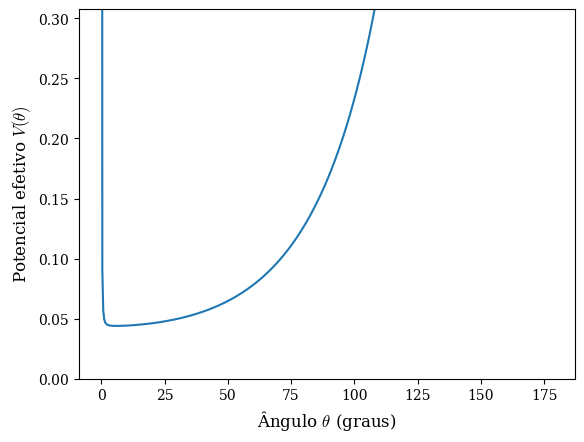

In [11]:
#Para evitar divergência, excluímos 0 e pi do linspace
thetas = np.linspace(0.001,0.99*np.pi,500)
potencial = V(thetas)

plt.plot(np.degrees(thetas), potencial)
plt.ylim(0, min(potencial)*7)
plt.ylabel(r"Potencial efetivo $V(\theta)$")
plt.xlabel(r"Ângulo $\theta$ (graus)")
plt.show()

Esse gráfico é muito interessante. Nota-se que seu mínimo está em uma região entre 0° e 10°. Além disso, o crescimento para ângulos maiores é muito mais suave que para ângulos menores, como era de se esperar. Como o potencial diverge para ângulo nulo, isso significa que para uma dada energia modificada ($E'$), o pião sai da posição inicial de 5° , percorre uma angulação considerável crescente e, quando retorna, não diminui muito de seu valor inicial.

### 3.2 Trajetória da cabeça do pião

Agora, chegamos na parte principal de nosso trabalho. O bloco de código a seguir é exclusivamente para a integração temporal dos ângulos de Euler usando a rotina `RK45` da *SciPy*.

In [12]:
def sistema_piao(t, y, I, I3, m, g, l, p_phi, p_psi):
    theta, phi, psi, theta_dot = y #Vetor das grandezas que serão usadas como base para a integração. Atualizadas a cada passo. 
    
    # 1. Calculamos as velocidades angulares atuais baseadas no theta atual
    # Adicionamos um pequeno 1e-9 para evitar divisão por zero se theta for 0
    sin_theta = np.sin(theta)
    if abs(sin_theta) < 1e-9: sin_theta = 1e-9 

    #Cálculo das velocidades de precessão e revolução instantânea
    phi_dot = (p_phi - p_psi * np.cos(theta)) / (I * sin_theta**2)
    psi_dot = (p_psi / I3) - phi_dot * np.cos(theta)
    
    # 2. A aceleração de theta vem da equação de Lagrange
    theta_ddot = (phi_dot**2 * np.sin(theta) * np.cos(theta)) - \
                 (1/I * p_psi * phi_dot * np.sin(theta)) + \
                 (m * g * l * np.sin(theta) / I)
                 
    return [theta_dot, phi_dot, psi_dot, theta_ddot]

# --- Integração ---

t_span = (0, 5) # 5 segundos de simulação
t_eval = np.linspace(0, 5, 2000)
y0 = [theta_0, 0, 0, theta_dot0] # [theta, phi, psi, theta_dot]

sol = solve_ivp(sistema_piao, t_span, y0, t_eval=t_eval, 
                args=(I, I3, m, g, l, p_phi, p_psi), method='RK45')

# Agora que temos theta em função do tempo:
thetas_t = sol.y[0]
phis_t = sol.y[1]
psis_t = sol.y[2]
tempos = sol.t

Com a solução armazenada, vamos rastrear a extremidade do pião, que fica no ponto mais alto do eixo de simetria do corpo. Com esse pont determinado, sabemos inteiramente o modo como o pião está localizado, ou seja, determinamos a posição do pião por completo em cada momento. Para melhor visualização, normalizamos os eixos, ou seja, as medidas estão dadas em unidades do comprimento total do pião. Por exemplo, 0.5 no eixo $z$ representaria uma altura equivalente à metade da altura do pião.

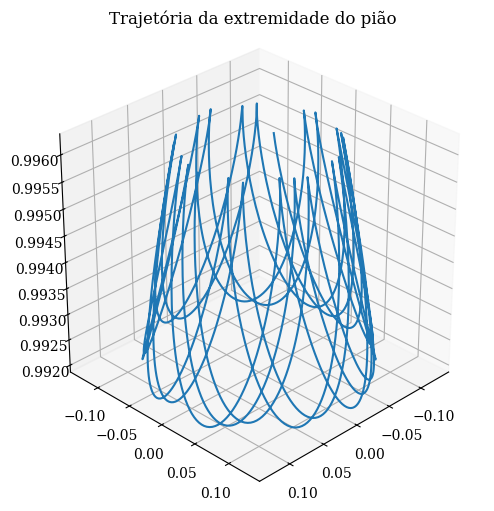

In [13]:
x =  np.sin(thetas_t) * np.cos(phis_t)
y =  np.sin(thetas_t) * np.sin(phis_t)
z =  np.cos(thetas_t)

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
ax.plot(x, y, z, lw=1.5)
ax.view_init(elev=30, azim=45)
ax.set_box_aspect([1,1,1])
plt.title("Trajetória da extremidade do pião")
plt.show()

Com o gráfico, vemos que o pião apresenta um movimento tipo cúspide. Pelos eixos, percebemos também que a variação total de $\theta$ foi muito baixa. Isso significa que o pião mal saiu da sua inclinação inicial. Na brincadeira, isso seria perfeito! A referência [1] confirma que esse tipo de movimento é o mais comum para esse sistema. A seguir, utilizamos de artifícios gráficos para gerar uma animação que ilustra o movimento do eixo de simetria do pião durante o intervalo de tempo que a integração é feita.

In [14]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# Criamos os objetos que serão atualizados: o eixo do pião e o rastro (trajetória)
linha_eixo, = ax.plot([], [], [], 'k-', lw=3)       # Eixo físico do pião
rastro, = ax.plot([], [], [], 'b-', alpha=0.5)      # Caminho percorrido
ponta, = ax.plot([], [], [], 'ro')                  # A extremidade superior

# Definindo os limites do gráfico (importante para não "pular")
max_range = 1
ax.set_xlim(-max_range, max_range)
ax.set_ylim(-max_range, max_range)
ax.set_zlim(0, max_range)
ax.set_title("Simulação da extremidade do pião")

def atualizar(i):
    # Atualiza o rastro até o frame atual
    rastro.set_data(x[:i], y[:i])
    rastro.set_3d_properties(z[:i])
    
    # Desenha o eixo do pião (da origem [0,0,0] até a posição atual [x,y,z])
    linha_eixo.set_data([0, x[i]], [0, y[i]])
    linha_eixo.set_3d_properties([0, z[i]])
    
    # Atualiza a pontinha
    ponta.set_data([x[i]], [y[i]])
    ponta.set_3d_properties([z[i]])
    ax.view_init(elev=20, azim=45)
    
    return linha_eixo, rastro, ponta

# Passamos uma lista de índices: 0, 5, 10, 15... até o fim do array
indices_animacao = range(0, len(x), 10) 


ani = FuncAnimation(fig, atualizar, frames=indices_animacao, interval=30, blit=False)

# 2. Impede que o gráfico estático apareça
plt.close(fig)
ani.save('meu_piao.gif', writer='pillow', fps=30)

<img src="../Imagens/pião/meu_piao.gif" width="800">

A seguir, faremos a mesma coisa que anteriormente. A única diferença será as condições iniciais, que apresentam grande diferença, que refletirá na trajetória seguida pelo pião. Para uma integração automática, usamos laços para realizar os cálculos com as duas velocidades distintas. Para os casos a seguir, a inclinação inicial foi tomada como $\theta_0 = 30°$. A velocidade de revolução própria foi mantida. Porém, a de precessão é o que difere os dois casos. Na primeira, a velocidade aponta no sentido contrário da tendência de giro do pião, enquanto a segunda tem uma velocidade na mesma direção. Os valores adotados estão explicitados no código a seguir.

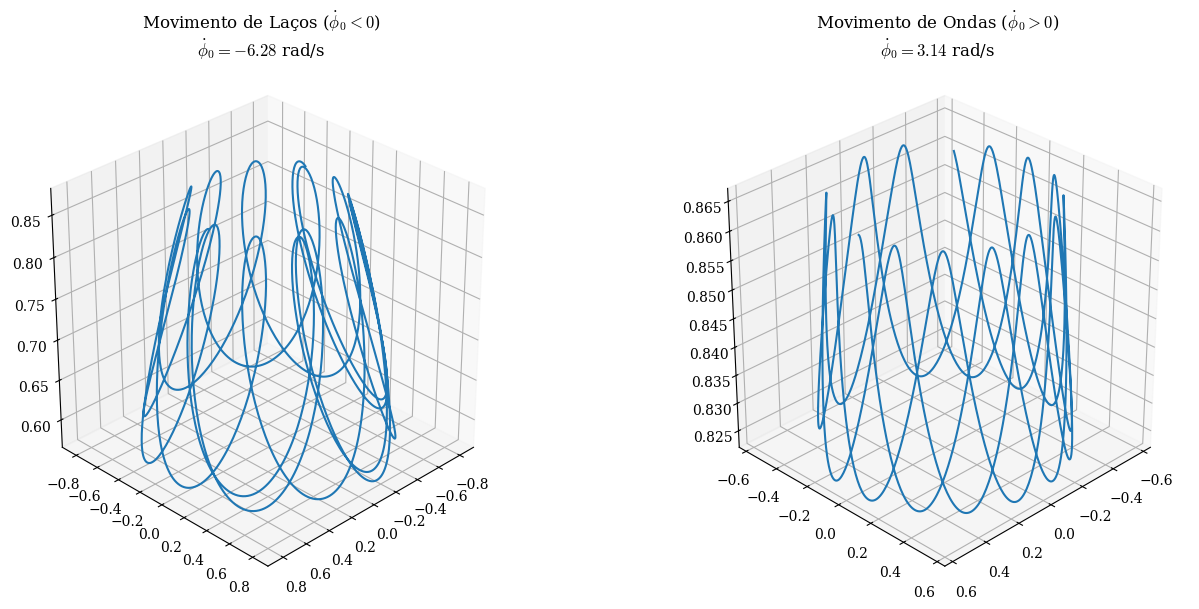

In [15]:
#Novo ângulo inicial
theta_0 = np.radians(30)

# 2. Configurando a figura com 2 subplots 3D lado a lado
fig = plt.figure(figsize=(14, 6))

# Valores de velocidade de precessão que vamos testar
velocidades = [-2*np.pi, np.pi]
titulos = ["Movimento de Laços ($\\dot{\\phi}_0 < 0$)", "Movimento de Ondas ($\\dot{\\phi}_0 > 0$)"]

# 3. O "For" que percorre os casos
for i, phi_dot0 in enumerate(velocidades):
    
    # ATENÇÃO: Recalculamos os momentos DENTRO do loop 
    # pois eles mudam para cada velocidade inicial!
    p_psi = I3 * (psi_dot0 + phi_dot0 * np.cos(theta_0))
    p_phi = (I * np.sin(theta_0)**2 + I3 * np.cos(theta_0)**2) * phi_dot0 + I3 * psi_dot0 * np.cos(theta_0)

    # Definimos a função do sistema usando valores padrão na assinatura
    # Isso evita que o Python confunda os p_phi e p_psi nas iterações do loop
    def sistema(t, y, p_phi_atual=p_phi, p_psi_atual=p_psi):
        theta, phi, psi, theta_dot = y
        sin_theta = np.sin(theta)
        if abs(sin_theta) < 1e-9: sin_theta = 1e-9 
        
        phi_dot = (p_phi_atual - p_psi_atual * np.cos(theta)) / (I * sin_theta**2)
        psi_dot = (p_psi_atual / I3) - phi_dot * np.cos(theta)
        
        theta_ddot = (phi_dot**2 * np.sin(theta) * np.cos(theta)) - \
                     (1/I * p_psi_atual * phi_dot * np.sin(theta)) + \
                     (m * g * l * np.sin(theta) / I)
        return [theta_dot, phi_dot, psi_dot, theta_ddot]

    # Integração
    sol = solve_ivp(sistema, [0, 3], [theta_0, 0, 0, theta_dot0], 
                    t_eval=np.linspace(0, 3, 2000), method='RK45')

    # Convertendo para Cartesianas na Esfera Unitária
    x = np.sin(sol.y[0]) * np.cos(sol.y[1])
    y = np.sin(sol.y[0]) * np.sin(sol.y[1])
    z = np.cos(sol.y[0])

    # 4. Plotando no Subplot correto (1 ou 2)
    ax = fig.add_subplot(1, 2, i + 1, projection='3d')
    ax.plot(x, y, z, lw=1.5)
    
    # Estética
    ax.set_title(f"{titulos[i]}\n$\\dot{{\\phi}}_0 = {phi_dot0:.2f}$ rad/s", pad=15)
    ax.view_init(elev=30, azim=45)
    ax.set_box_aspect([1,1,1])

plt.tight_layout()
plt.show()

Para finalizar com chave de ouro, elaboramos animações análogas à primeira, retratanto o movimento do eixo de simetria do pião para os dois casos. O bloco de código para fabricar essa animação é bem complexo, mas gera um resultado espetacular!

In [16]:
# 2. Função "Fábrica" de Trajetórias (Evita mistura de variáveis)
def simular_trajetoria(phi_dot_inicial, t_max=5.0, num_pontos=1000):
    # Calcula momentos específicos para ESTA velocidade
    p_psi = I3 * (psi_dot0 + phi_dot_inicial * np.cos(theta_0))
    p_phi = (I * np.sin(theta_0)**2 + I3 * np.cos(theta_0)**2) * phi_dot_inicial + I3 * psi_dot0 * np.cos(theta_0)
    
    def sistema(t, y):
        theta, phi, psi, theta_dot = y
        sin_theta = max(abs(np.sin(theta)), 1e-9) * np.sign(np.sin(theta) or 1)
        
        phi_dot = (p_phi - p_psi * np.cos(theta)) / (I * sin_theta**2)
        psi_dot = (p_psi / I3) - phi_dot * np.cos(theta)
        
        theta_ddot = (phi_dot**2 * np.sin(theta) * np.cos(theta)) - \
                     (1/I * p_psi * phi_dot * np.sin(theta)) + \
                     (m * g * l * np.sin(theta) / I)
        return [theta_dot, phi_dot, psi_dot, theta_ddot]

    sol = solve_ivp(sistema, [0, t_max], [theta_0, 0, 0, theta_dot0], 
                    t_eval=np.linspace(0, t_max, num_pontos), method='RK45')
    
    # Retorna X, Y, Z na esfera unitária
    x = np.sin(sol.y[0]) * np.cos(sol.y[1])
    y = np.sin(sol.y[0]) * np.sin(sol.y[1])
    z = np.cos(sol.y[0])
    return x, y, z

# --- GERANDO OS DADOS ---
# Pião 1 (Laços) e Pião 2 (Ondas)
x1, y1, z1 = simular_trajetoria(-2 * np.pi)
x2, y2, z2 = simular_trajetoria(np.pi)

# --- CONFIGURANDO A ANIMAÇÃO DUPLA ---
fig = plt.figure(figsize=(14, 6))

# Configuração do Subplot 1 (Laços)
ax1 = fig.add_subplot(121, projection='3d')
ax1.set_title("Movimento de Laços ($\\dot{\\phi}_0 = -2\\pi$)", pad=15)
rastro1, = ax1.plot([], [], [], 'b-', alpha=0.6)
eixo1, = ax1.plot([], [], [], 'k-', lw=3)
ponta1, = ax1.plot([], [], [], 'ro')

# Configuração do Subplot 2 (Ondas)
ax2 = fig.add_subplot(122, projection='3d')
ax2.set_title("Movimento de Ondas ($\\dot{\\phi}_0 = \\pi$)", pad=15)
rastro2, = ax2.plot([], [], [], 'g-', alpha=0.6)
eixo2, = ax2.plot([], [], [], 'k-', lw=3)
ponta2, = ax2.plot([], [], [], 'ro')

# Ajustes visuais estáticos para ambos os eixos
phi_circ = np.linspace(0, 2*np.pi, 100)
xc, yc, zc = np.sin(theta_0)*np.cos(phi_circ), np.sin(theta_0)*np.sin(phi_circ), np.full_like(phi_circ, np.cos(theta_0))

for ax in [ax1, ax2]:
    ax.set_box_aspect([1,1,1])
    ax.axis('off')
    ax.set_xlim(-1, 1); ax.set_ylim(-1, 1); ax.set_zlim(0, 1)
    ax.plot(xc, yc, zc, 'r--', alpha=0.3) # Linha guia vermelha

# --- FUNÇÃO DE ATUALIZAÇÃO ---
def atualizar(i):
    # Atualiza Pião 1
    rastro1.set_data(x1[:i], y1[:i]); rastro1.set_3d_properties(z1[:i])
    eixo1.set_data([0, x1[i]], [0, y1[i]]); eixo1.set_3d_properties([0, z1[i]])
    ponta1.set_data([x1[i]], [y1[i]]); ponta1.set_3d_properties([z1[i]])
    ax1.view_init(elev=25, azim=i*0.1) # Câmera gira bem devagar
    
    # Atualiza Pião 2
    rastro2.set_data(x2[:i], y2[:i]); rastro2.set_3d_properties(z2[:i])
    eixo2.set_data([0, x2[i]], [0, y2[i]]); eixo2.set_3d_properties([0, z2[i]])
    ponta2.set_data([x2[i]], [y2[i]]); ponta2.set_3d_properties([z2[i]])
    ax2.view_init(elev=25, azim=i*0.1)
    
    return rastro1, eixo1, ponta1, rastro2, eixo2, ponta2

# Criando a animação pulando de 3 em 3 frames para ficar fluido
indices = range(0, len(x1), 3)
ani = FuncAnimation(fig, atualizar, frames=indices, interval=30, blit=False)

# 2. Impede que o gráfico estático apareça
plt.close(fig) 
# Exibe no Notebook
ani.save('meu_piao2.gif', writer='pillow', fps=30)

<img src="../Imagens/pião/meu_piao2.gif" width="1000">

$\quad$ É importante perceber que os movimentos de laços e ondas não costumam ser visualizados nos instantes iniciais após um lançamento bem-executado. Na verdade, observamos padrões parecidos com esses — principalmente o movimento de ondas — após algum tempo de rotação, quando as forças resistivas (como o atrito no ponto de apoio e a resistência do ar) começam a dissipar a energia do sistema.

$\quad$ Fisicamente, isso ocorre pois o decaimento do momento de revolução ($p_\psi$) e da energia total altera o balanço entre o torque gravitacional e o efeito giroscópico. A velocidade de precessão média se ajusta, e o pião, que antes descrevia cúspides perfeitas, passa a apresentar uma nutação mais suave ou precessão regular. Portanto, os três cenários simulados funcionam como 'fotografias' de estágios distintos da vida útil do movimento de um pião real.

## Conclusão

$\quad$ Neste `Notebook`, exploramos a dinâmica de corpos rígidos em muitos aspectos. Deduzimos e apresentamos grande parte desse formalismo da mecânica analítica. Como ponto chave, fizemos uma aplicação desse conhecimento: o estudo de um pião simétrico com ponto fixo sobre ação da gravidade. Mostramos como a mecânica Lagrangiana pode ser auxiliadora nesse tipo de problema. Entretanto, chegamos em um grande problema: a solução analítica não é dada em termos de funções elementares. 

$\quad$ Para resolver essa dificuldade, usamos o problema do valor inicial para resolução numérica das equações de movimento. Utilizamos uma rotina de integração disponível na biblioteca *SciPy*, que se mostrou extremamente estável e eficiente. Assumindo valores iniciais consistentes, obtemos as constantes de movimento associadas ao pião, que nos permitiu visualizar o comportamento do potencial efetivoo a depender do ângulo de nutação $\theta$.

$\quad$ Por fim, com o auxílio da função de integração temporal, obtivemos as soluções para os três ângulos de Euler, os graus de liberdade do nosso sistema. A fim de visualização completa dos possíveis resultados, realizamos a integração para diferentes condições iniciais, revelando fenômenos como a precessão e a nutação. Com isso, fizemos gráficos 3D que ilustram a trajetória do ponto mais alto do seu eixo de simetria, identificando padrões como laços e cúspides. Com esse gráfico, identificamos completamente a posição do pião com o passar do tempo. Além disso, geramos animações mostrando o movimento do eixo por completo, simulando a visualização real do pião.

$\quad$ Em geral, esse `Notebook` teve como objetivo ilustrar e explicar um grande brinquedo: o pião. No correr do texto, mostramos as condições para o lançamento tradicional e mais adequado (tipo cúspide). Também mostramos o comportamento do pião para outras condições, que podem ser aproximadas como estágios intermediários do lançamento completo do pião. Portanto, podemos concluir que nosso objetivo foi concluído com êxito! Agora, sabemos soltar um pião da melhor forma!

## Referências

[1] Thorton, Stephen; Marrion, Jerry. 2011. Dinâmica Clássica de Partículas e Sistemas. 5 ed.

[2] Lemos, Nivaldo. 2007. Mecânica Analítica. 2 ed.

[3] Newman, Mark. 2013. Computational Physics. 1 ed.

[4] SCIPY COMMUNITY. scipy.integrate.solve_ivp. SciPy v1.13.0 Documentation, 2024. Disponível em: https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.solve_ivp.html.